Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Loading data from: /content/drive/MyDrive/CryptoProject/processed_data_transformer/ETHUSDT
Epoch 1/40 | Train Loss: 0.066283 | Val Loss: 0.063927
Epoch 2/40 | Train Loss: 0.064543 | Val Loss: 0.063596
Epoch 3/40 | Train Loss: 0.064277 | Val Loss: 0.063556
Epoch 4/40 | Train Loss: 0.064085 | Val Loss: 0.065139
EarlyStopping counter: 1 out of 30
Epoch 5/40 | Train Loss: 0.064018 | Val Loss: 0.063432
Epoch 6/40 | Train Loss: 0.063909 | Val Loss: 0.063663
EarlyStopping counter: 1 out of 30
Epoch 7/40 | Train Loss: 0.063884 | Val Loss: 0.063506
EarlyStopping counter: 2 out of 30
Epoch 8/40 | Train Loss: 0.063800 | Val Loss: 0.063481
EarlyStopping counter: 3 out of 30
Epoch 9/40 | Train Loss: 0.063742 | Val Loss: 0.063797
EarlyStopping counter: 4 out of 30
Epoch 10/40 | Train Loss: 0.063699 | Val Loss: 0.063459
EarlyStopping counter: 5 out of 30


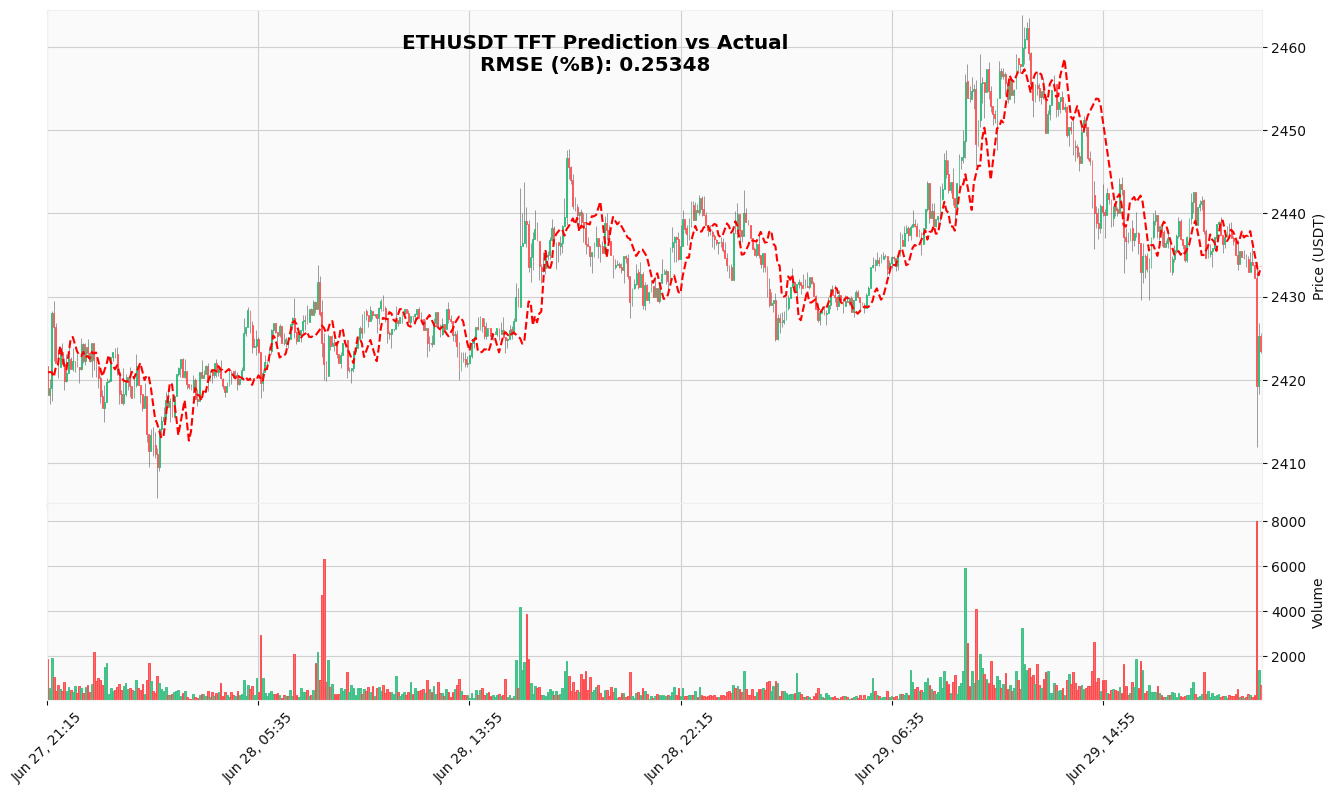

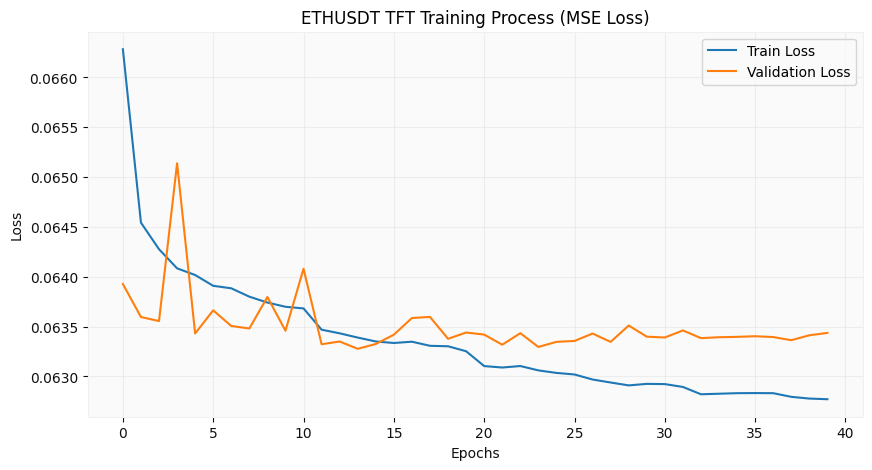

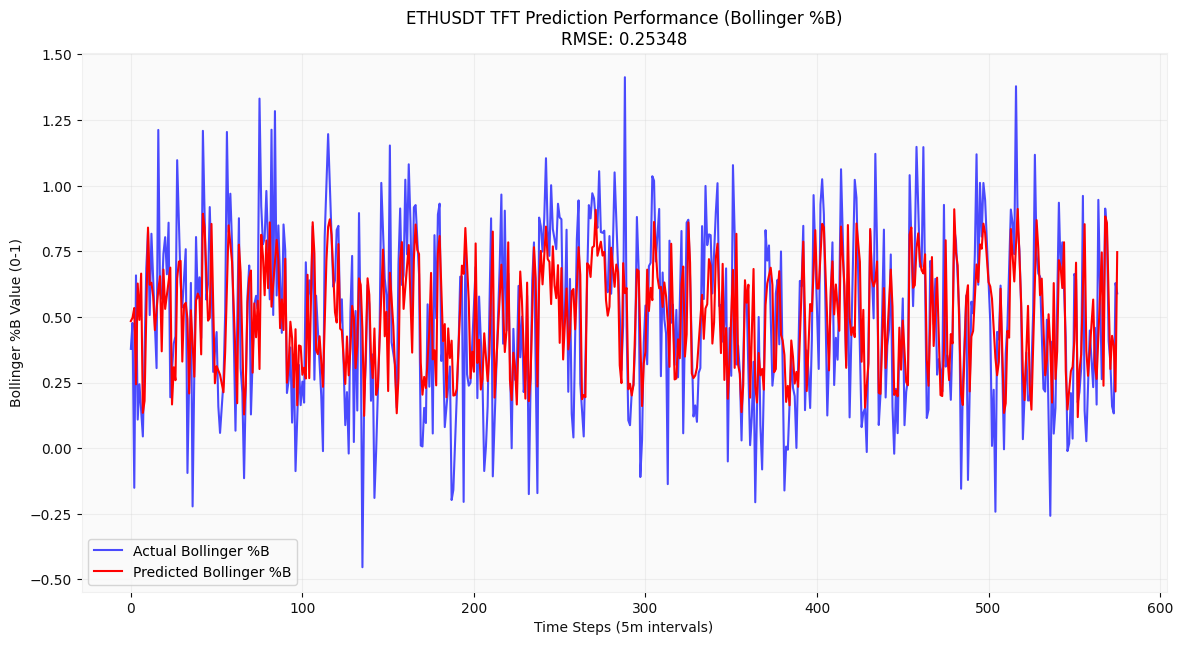


--- Accuracy on Strong Moves (Threshold 0.002): 52.31% (4049/18181 candles) ---


In [3]:
%pip install torch ta mplfinance scikit-learn matplotlib pandas

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import mplfinance as mpf
import pandas as pd
import math
import ta

# --- הגדרת המטבע ---
SYMBOL = 'ETHUSDT'

# --- 1. חיבור לגוגל דרייב ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/CryptoProject'
except ImportError:
    BASE_DIR = os.getcwd()

# --- הגדרות נתיבים מעודכנות לפי המטבע ---
DATA_DIR = os.path.join(BASE_DIR, 'processed_data_transformer', SYMBOL)
MODEL_DIR = os.path.join(BASE_DIR, 'models')
if not os.path.exists(MODEL_DIR): os.makedirs(MODEL_DIR)

BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 0.001
D_MODEL = 16
N_HEADS = 4
NUM_LAYERS = 1
DROPOUT = 0.4

# ---------------------------------------------------------
# 1. TFT Components: GLU, GRN, VSN
# ---------------------------------------------------------
class GLU(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc = nn.Linear(input_size, input_size * 2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc(x)
        content, gate = torch.chunk(x, 2, dim=-1)
        return content * self.sigmoid(gate)

class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=None, dropout=0.1):
        super().__init__()
        output_size = output_size or input_size
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.glu = GLU(output_size)
        self.layer_norm = nn.LayerNorm(output_size)
        self.dropout = nn.Dropout(dropout)
        self.skip = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.dropout(x)
        x = self.glu(x)
        return self.layer_norm(residual + x)

class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_dim, num_vars, d_model, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_vars = num_vars
        self.grns = nn.ModuleList([GRN(input_dim // num_vars, d_model, d_model, dropout) for _ in range(num_vars)])
        self.selector_grn = GRN(input_dim, d_model, num_vars, dropout)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        # x shape: (batch, seq, input_dim)
        weights = self.softmax(self.selector_grn(x)) # (batch, seq, num_vars)

        var_outputs = []
        chunk_size = x.shape[-1] // self.num_vars
        for i in range(self.num_vars):
            var_x = x[..., i*chunk_size : (i+1)*chunk_size]
            var_outputs.append(self.grns[i](var_x)) # (batch, seq, d_model)

        var_outputs = torch.stack(var_outputs, dim=-1) # (batch, seq, d_model, num_vars)
        selected_output = torch.sum(var_outputs * weights.unsqueeze(-2), dim=-1)
        return selected_output

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TFTModel(nn.Module):
    def __init__(self, input_dim, num_vars, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.vsn = VariableSelectionNetwork(input_dim, num_vars, d_model, dropout)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, d_model*4, dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.vsn(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return torch.sigmoid(self.fc(x[:, -1, :]))

def calculate_directional_accuracy(y_true, y_pred, threshold=0.001):
    true_change = np.diff(y_true) / y_true[:-1]
    pred_change = np.diff(y_pred) / y_pred[:-1]
    significant_moves_mask = np.abs(true_change) > threshold

    if np.sum(significant_moves_mask) == 0:
        print("No significant moves in true data.")
        return 0.0

    true_direction = np.sign(true_change[significant_moves_mask])
    pred_direction = np.sign(pred_change[significant_moves_mask])
    correct = np.sum(true_direction == pred_direction)
    total = len(true_direction)

    accuracy = (correct / total) * 100
    print(f"\n--- Accuracy on Strong Moves (Threshold {threshold}): {accuracy:.2f}% ({total}/{len(y_pred)} candles) ---")
    return accuracy

# ---------------------------------------------------------
# 2. Training Logic
# ---------------------------------------------------------
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_loss = np.inf

    def __call__(self, val_loss, model, model_save_path):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model, model_save_path)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model, model_save_path)
            self.counter = 0

    def save_checkpoint(self, val_loss, model, model_save_path):
        torch.save(model.state_dict(), model_save_path)
        self.best_loss = val_loss

def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    print(f"Loading data from: {DATA_DIR}")

    X_train = torch.tensor(np.load(os.path.join(DATA_DIR, 'X_train.npy')), dtype=torch.float32).to(device)
    y_train = torch.tensor(np.load(os.path.join(DATA_DIR, 'y_train.npy')), dtype=torch.float32).to(device)
    X_val = torch.tensor(np.load(os.path.join(DATA_DIR, 'X_val.npy')), dtype=torch.float32).to(device)
    y_val = torch.tensor(np.load(os.path.join(DATA_DIR, 'y_val.npy')), dtype=torch.float32).to(device)
    X_test = torch.tensor(np.load(os.path.join(DATA_DIR, 'X_test.npy')), dtype=torch.float32).to(device)
    y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

    model = TFTModel(input_dim=X_train.shape[2], num_vars=X_train.shape[2], d_model=D_MODEL).to(device)

    # HuberLoss is better balanced for values like %B (0-1 range)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    model_save_path = os.path.join(MODEL_DIR, f'best_tft_vsn_{SYMBOL}.pth')
    early_stopping = EarlyStopping(patience=30, verbose=True, delta=1e-6)

    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        for bx, by in train_loader:
            optimizer.zero_grad()
            pred = model(bx).squeeze()
            loss = criterion(pred, by)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                pred = model(bx).squeeze()
                total_val_loss += criterion(pred, by).item()

        avg_val = total_val_loss / len(val_loader)
        scheduler.step(avg_val)
        train_losses.append(total_train_loss/len(train_loader))
        val_losses.append(avg_val)
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {total_train_loss/len(train_loader):.6f} | Val Loss: {avg_val:.6f}")

        early_stopping(avg_val, model, model_save_path)
        if early_stopping.early_stop:
            print("Early stopping")
            break

    # Evaluation
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test), BATCH_SIZE):
            preds.extend(model(X_test[i:i+BATCH_SIZE]).squeeze().cpu().numpy())

    # Visualization Reconstruct to match LSTM
    csv_path = os.path.join(BASE_DIR, 'data', f'{SYMBOL}_5m_data.csv')
    df_full = pd.read_csv(csv_path)
    df_full['open_time'] = pd.to_datetime(df_full['open_time'])
    df_full.set_index('open_time', inplace=True)

    SEQ_LENGTH = 60
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1

    n = len(df_full)
    train_end = int(n * TRAIN_SPLIT)
    val_end = int(n * (TRAIN_SPLIT + VAL_SPLIT))
    test_start_index = val_end + SEQ_LENGTH

    df_test_candles = df_full.iloc[test_start_index : test_start_index + len(preds)].copy()

    bb = ta.volatility.BollingerBands(df_full['close'], window=20, window_dev=2)
    upper_band = bb.bollinger_hband().iloc[test_start_index : test_start_index + len(preds)].values
    lower_band = bb.bollinger_lband().iloc[test_start_index : test_start_index + len(preds)].values

    predicted_price = lower_band + (np.array(preds) * (upper_band - lower_band))
    df_test_candles['Predicted_Close'] = pd.Series(predicted_price).rolling(window=3).mean().bfill().values

    ZOOM_SAMPLES = 576
    df_plot = df_test_candles.head(ZOOM_SAMPLES)

    rmse = np.sqrt(mean_squared_error(y_test, np.array(preds)))

    apdict = mpf.make_addplot(df_plot['Predicted_Close'], type='line', color='red', linestyle='--', width=1.5, panel=0)
    title_text = f'{SYMBOL} TFT Prediction vs Actual\nRMSE (%B): {rmse:.5f}'

    mpf.plot(
        df_plot, type='candle', style='yahoo', addplot=apdict, volume=True,
        title=title_text, ylabel='Price (USDT)', figsize=(14, 8), tight_layout=True
    )

    # 1. Plot Training vs Validation Loss
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'{SYMBOL} TFT Training Process (MSE Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 2. Plot Raw %B Target vs Prediction
    plt.figure(figsize=(14, 7))
    plt.plot(y_test[:576], label='Actual Bollinger %B', color='blue', alpha=0.7)
    plt.plot(preds[:576], label='Predicted Bollinger %B', color='red', linewidth=1.5)
    plt.title(f'{SYMBOL} TFT Prediction Performance (Bollinger %B)\nRMSE: {rmse:.5f}')
    plt.xlabel('Time Steps (5m intervals)')
    plt.ylabel('Bollinger %B Value (0-1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    actual_prices = df_test_candles['close'].values
    calculate_directional_accuracy(actual_prices, predicted_price, threshold=0.002)

if __name__ == "__main__":
    train()